# Assignment 3
# User segmentation using clustering

Ghazal Moosavi

In [ ]:
import pandas as pd
import numpy as np
import csv

In [ ]:
orders      = pd.read_csv('olist_orders_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
payments = pd.read_csv(
    'olist_order_payments_dataset.csv'
)
reviews = pd.read_csv(
    'olist_order_reviews_dataset.csv'
)
customers   = pd.read_csv('olist_customers_dataset.csv')
geoloc      = pd.read_csv('olist_geolocation_dataset.csv')
products    = pd.read_csv('olist_products_dataset.csv')
sellers     = pd.read_csv('olist_sellers_dataset.csv')
cat_trans   = pd.read_csv('product_category_name_translation.csv')



---



## Data Pre-processing

In [ ]:
orders.shape

(99441, 8)

In [ ]:
orders.info()
orders.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [ ]:
orders.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [ ]:
(orders.isnull().mean() * 100).round(2)

,0
order_id,0.00
customer_id,0.00
order_status,0.00
order_purchase_timestamp,0.00
order_approved_at,0.16
order_delivered_carrier_date,1.79
order_delivered_customer_date,2.98
order_estimated_delivery_date,0.00


In [ ]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')
for col in date_cols:
    median_ts = orders[col].median()
    orders[col] = orders[col].fillna(median_ts)

In [ ]:
orders.info()
orders.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99441 non-null  datetime64[ns]
 5   order_delivered_carrier_date   99441 non-null  datetime64[ns]
 6   order_delivered_customer_date  99441 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26




---



order_items

In [ ]:
order_items.shape

(112650, 7)

In [ ]:
order_items.info()
order_items.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [ ]:
order_items.isnull().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


In [ ]:
order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'], errors='coerce')

In [ ]:
order_items.info()
order_items.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  object        
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  object        
 3   seller_id            112650 non-null  object        
 4   shipping_limit_date  112650 non-null  datetime64[ns]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 6.0+ MB


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14




---



payments


In [ ]:
payments.shape

(103886, 5)

In [ ]:
payments.info()
payments.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [ ]:
payments.isnull().sum()

,0
order_id,0
payment_sequential,0
payment_type,0
payment_installments,0
payment_value,0


In [ ]:
Q1 = payments['payment_value'].quantile(0.25)
Q3 = payments['payment_value'].quantile(0.75)
IQR = Q3 - Q1
payments = payments[(payments['payment_value'] >= Q1 - 1.5 * IQR) &
                    (payments['payment_value'] <= Q3 + 1.5 * IQR)]

In [ ]:
payments.info()
payments.head()

<class 'pandas.core.frame.DataFrame'>
Index: 95905 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   order_id              95905 non-null  object 
 1   payment_sequential    95905 non-null  int64  
 2   payment_type          95905 non-null  object 
 3   payment_installments  95905 non-null  int64  
 4   payment_value         95905 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.4+ MB


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45




---



reviews

In [ ]:
reviews.shape

(99224, 7)

In [ ]:
reviews.info()
reviews .head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [ ]:
reviews.isnull().sum()

,0
review_id,0
order_id,0
review_score,0
review_comment_title,87656
review_comment_message,58247
review_creation_date,0
review_answer_timestamp,0


In [ ]:
(reviews.isnull().mean() * 100).round(2)

,0
review_id,0.00
order_id,0.00
review_score,0.00
review_comment_title,88.34
review_comment_message,58.70
review_creation_date,0.00
review_answer_timestamp,0.00


In [ ]:
reviews = reviews.drop(columns=['review_comment_title'])

In [ ]:
reviews['has_message'] = reviews['review_comment_message'].notnull().astype(int)

In [ ]:
reviews['review_comment_message'] = reviews['review_comment_message'].fillna('No comment')

In [ ]:
reviews.info()
reviews.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_message   99224 non-null  object
 4   review_creation_date     99224 non-null  object
 5   review_answer_timestamp  99224 non-null  object
 6   has_message              99224 non-null  int64 
dtypes: int64(2), object(5)
memory usage: 5.3+ MB


,review_id,order_id,review_score,review_comment_message,review_creation_date,review_answer_timestamp,has_message
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,No comment,2018-01-18 00:00:00,2018-01-18 21:46:59,0
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,No comment,2018-03-10 00:00:00,2018-03-11 03:05:13,0
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,No comment,2018-02-17 00:00:00,2018-02-18 14:36:24,0
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06,1
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53,1




---



customers

In [ ]:
customers.shape

(99441, 5)

In [ ]:
customers.info()
customers .head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [ ]:
customers.isnull().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0




---



geoloc

In [ ]:
geoloc.shape

(1000163, 5)

In [ ]:
geoloc.info()
geoloc.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [ ]:
geoloc.isnull().sum()

,0
geolocation_zip_code_prefix,0
geolocation_lat,0
geolocation_lng,0
geolocation_city,0
geolocation_state,0




---




products

In [ ]:
products.shape

(32951, 9)

In [ ]:
products.info()  #before cleaning
products.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [ ]:
products.isnull().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [ ]:
(products.isnull().mean() * 100).round(2)

,0
product_id,0.00
product_category_name,1.85
product_name_lenght,1.85
product_description_lenght,1.85
product_photos_qty,1.85
product_weight_g,0.01
product_length_cm,0.01
product_height_cm,0.01
product_width_cm,0.01


In [ ]:
products = products[products['product_category_name'].notnull()]

In [ ]:
for col in ['product_weight_g','product_length_cm','product_height_cm','product_width_cm']:
    median = products[col].median()
    products[col] = products[col].fillna(median)

In [ ]:
upper_limit = products['product_weight_g'].quantile(0.995)
products = products[(products['product_weight_g'] > 0) & (products['product_weight_g'] < upper_limit)]

In [ ]:
products.info()   #after cleaning
products.head()

<class 'pandas.core.frame.DataFrame'>
Index: 32175 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32175 non-null  object 
 1   product_category_name       32175 non-null  object 
 2   product_name_lenght         32175 non-null  float64
 3   product_description_lenght  32175 non-null  float64
 4   product_photos_qty          32175 non-null  float64
 5   product_weight_g            32175 non-null  float64
 6   product_length_cm           32175 non-null  float64
 7   product_height_cm           32175 non-null  float64
 8   product_width_cm            32175 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.5+ MB


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0




---



sellers

In [ ]:
sellers.shape

(3095, 4)

In [ ]:
sellers.info()
sellers.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [ ]:
sellers.isnull().sum()

,0
seller_id,0
seller_zip_code_prefix,0
seller_city,0
seller_state,0




---



cat_trans

In [ ]:
cat_trans.shape

(71, 2)

In [ ]:
cat_trans.info()
cat_trans.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [ ]:
cat_trans.isnull().sum()

,0
product_category_name,0
product_category_name_english,0




---



merge and agg

In [ ]:
orders.dropna(subset=['customer_id','order_id'], inplace=True)
order_items.dropna(subset=['order_id'], inplace=True)
payments.dropna(subset=['order_id'], inplace=True)
reviews.dropna(subset=['order_id'], inplace=True)

In [ ]:
order_items = order_items.merge(products[['product_id','product_category_name']],
                    on='product_id', how='left')
order_items= order_items.merge(cat_trans, on='product_category_name', how='left')

ord_cust = orders.merge(customers, on='customer_id', how='inner')

df = ord_cust.merge(payments, on='order_id', how='left')

df = df.merge(order_items, on='order_id', how='left')

df = df.merge(reviews[['order_id','review_score']], on='order_id', how='left')


In [ ]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118954 entries, 0 to 118953
Data columns (total 25 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       118954 non-null  object        
 1   customer_id                    118954 non-null  object        
 2   order_status                   118954 non-null  object        
 3   order_purchase_timestamp       118954 non-null  datetime64[ns]
 4   order_approved_at              118954 non-null  datetime64[ns]
 5   order_delivered_carrier_date   118954 non-null  datetime64[ns]
 6   order_delivered_customer_date  118954 non-null  datetime64[ns]
 7   order_estimated_delivery_date  118954 non-null  datetime64[ns]
 8   customer_unique_id             118954 non-null  object        
 9   customer_zip_code_prefix       118954 non-null  int64         
 10  customer_city                  118954 non-null  object        
 11  

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,payment_value,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_category_name_english,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,18.12,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,housewares,4.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,2.00,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,housewares,4.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,18.59,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,housewares,4.0
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,141.46,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,perfumery,4.0
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,179.12,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,auto,5.0


In [ ]:
agg = df.groupby('customer_id').agg(
    num_orders         = ('order_id','nunique'),
    total_spent        = ('payment_value','sum'),
    avg_order_value    = ('payment_value','mean'),
    first_order_date   = ('order_purchase_timestamp','min'),
    last_order_date    = ('order_purchase_timestamp','max'),
    avg_review_score   = ('review_score','mean'),
    num_reviews        = ('review_score','count'),
)


In [ ]:
agg['active_days'] = (agg['last_order_date'] - agg['first_order_date']).dt.days
agg['avg_days_between'] = agg['active_days'] / agg['num_orders'].replace(1, np.nan)


In [ ]:
pay_mix = df.pivot_table(
    index='customer_id',
    columns='payment_type',
    values='payment_value',
    aggfunc='sum',
    fill_value=0
)
pay_mix_pct = pay_mix.div(pay_mix.sum(axis=1), axis=0).add_prefix('pct_')
agg = agg.join(pay_mix_pct, how='left').fillna(0)


In [ ]:
zip_coords = (
    geoloc
    .groupby('geolocation_zip_code_prefix')[['geolocation_lat','geolocation_lng']]
    .mean()
    .rename(columns={'geolocation_lat':'zip_lat','geolocation_lng':'zip_lng'})
)
cust_geo = (
    customers
    .set_index('customer_id')
    .join(zip_coords, on='customer_zip_code_prefix')
)
agg = agg.join(cust_geo[['zip_lat','zip_lng']], how='left')


In [ ]:
agg = agg.replace([np.inf, -np.inf], np.nan)
agg = agg.fillna(agg.median())


In [ ]:
features = agg.copy()

In [ ]:
features.info()
features.head()

<class 'pandas.core.frame.DataFrame'>
Index: 99441 entries, 00012a2ce6f8dcda20d059ce98491703 to ffffe8b65bbe3087b653a978c870db99
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   num_orders        99441 non-null  int64         
 1   total_spent       99441 non-null  float64       
 2   avg_order_value   99441 non-null  float64       
 3   first_order_date  99441 non-null  datetime64[ns]
 4   last_order_date   99441 non-null  datetime64[ns]
 5   avg_review_score  99441 non-null  float64       
 6   num_reviews       99441 non-null  int64         
 7   active_days       99441 non-null  int64         
 8   avg_days_between  99441 non-null  float64       
 9   pct_boleto        99441 non-null  float64       
 10  pct_credit_card   99441 non-null  float64       
 11  pct_debit_card    99441 non-null  float64       
 12  pct_not_defined   99441 non-null  float64       
 13  pct_voucher       99441

,num_orders,total_spent,avg_order_value,first_order_date,last_order_date,avg_review_score,num_reviews,active_days,avg_days_between,pct_boleto,pct_credit_card,pct_debit_card,pct_not_defined,pct_voucher,zip_lat,zip_lng,cluster
customer_id,,,,,,,,,,,,,,,,,
00012a2ce6f8dcda20d059ce98491703,1,114.74,114.74,2017-11-14 16:08:26,2017-11-14 16:08:26,1.0,1,0,0.0,0.0,1.0,0.0,0.0,0.0,-23.499063,-46.767939,2
000161a058600d5901f007fab4c27140,1,67.41,67.41,2017-07-16 09:40:32,2017-07-16 09:40:32,4.0,1,0,0.0,0.0,1.0,0.0,0.0,0.0,-20.469754,-45.123242,2
0001fd6190edaaf884bcaf3d49edf079,1,195.42,195.42,2017-02-28 11:06:43,2017-02-28 11:06:43,5.0,1,0,0.0,0.0,1.0,0.0,0.0,0.0,-18.706581,-40.406384,0
0002414f95344307404f0ace7a26f1d5,1,179.35,179.35,2017-08-16 13:09:20,2017-08-16 13:09:20,5.0,1,0,0.0,1.0,0.0,0.0,0.0,0.0,-21.770599,-43.355230,1
000379cdec625522490c315e70c7a9fb,1,107.01,107.01,2018-04-02 13:42:17,2018-04-02 13:42:17,4.0,1,0,0.0,1.0,0.0,0.0,0.0,0.0,-23.738709,-46.689333,1




---



## Exploratory Analysis

EDA

In [ ]:
features.describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]

,mean,std,min,25%,50%,75%,max
num_orders,1.0,0.0,1.0,1.0,1.0,1.0,1.0
total_spent,124.899194,131.383782,0.0,50.62,92.61,161.37,4118.31
avg_order_value,104.196422,75.37189,0.0,48.22,87.32,147.04,344.34
first_order_date,2017-12-31 08:43:12.776581120,NaN,2016-09-04 21:15:19,2017-09-12 14:46:19,2018-01-18 23:04:36,2018-05-04 15:42:16,2018-10-17 17:30:18
last_order_date,2017-12-31 08:43:12.776581120,NaN,2016-09-04 21:15:19,2017-09-12 14:46:19,2018-01-18 23:04:36,2018-05-04 15:42:16,2018-10-17 17:30:18
avg_review_score,4.05523,1.387967,0.0,4.0,5.0,5.0,5.0
num_reviews,1.186231,0.748249,0.0,1.0,1.0,1.0,63.0
active_days,0.0,0.0,0.0,0.0,0.0,0.0,0.0
avg_days_between,0.0,0.0,0.0,0.0,0.0,0.0,0.0
pct_boleto,0.18608,0.389173,0.0,0.0,0.0,0.0,1.0


Text(0.5, 0, 'Total Spent')

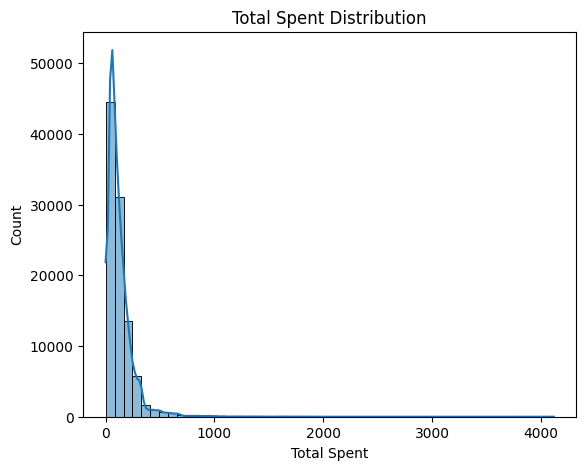

In [ ]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(features['total_spent'], bins=50, kde=True)
plt.title('Total Spent Distribution')
plt.xlabel('Total Spent')

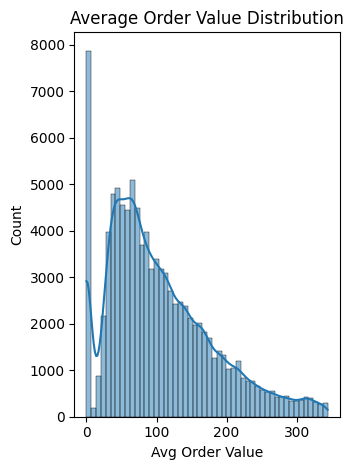

In [ ]:
plt.subplot(1, 2, 2)
sns.histplot(features['avg_order_value'], bins=50, kde=True)
plt.title('Average Order Value Distribution')
plt.xlabel('Avg Order Value')

plt.tight_layout()
plt.show()

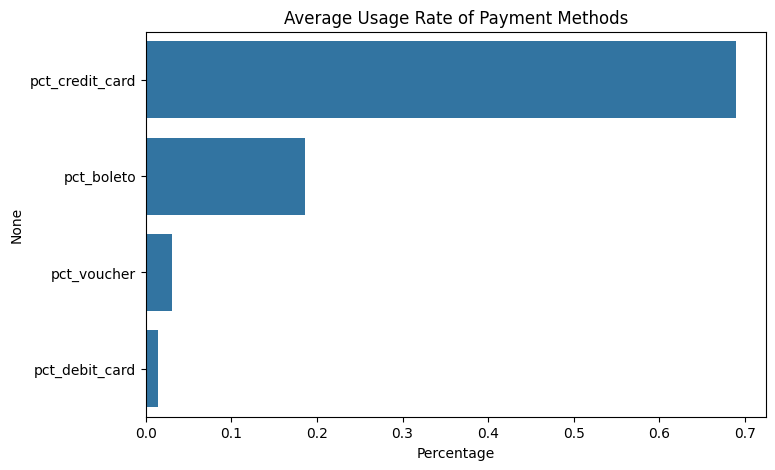

In [ ]:
payment_cols = ['pct_credit_card', 'pct_boleto', 'pct_debit_card', 'pct_voucher']

payment_means = features[payment_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=payment_means.values, y=payment_means.index)
plt.title('Average Usage Rate of Payment Methods')
plt.xlabel('Percentage')
plt.show()


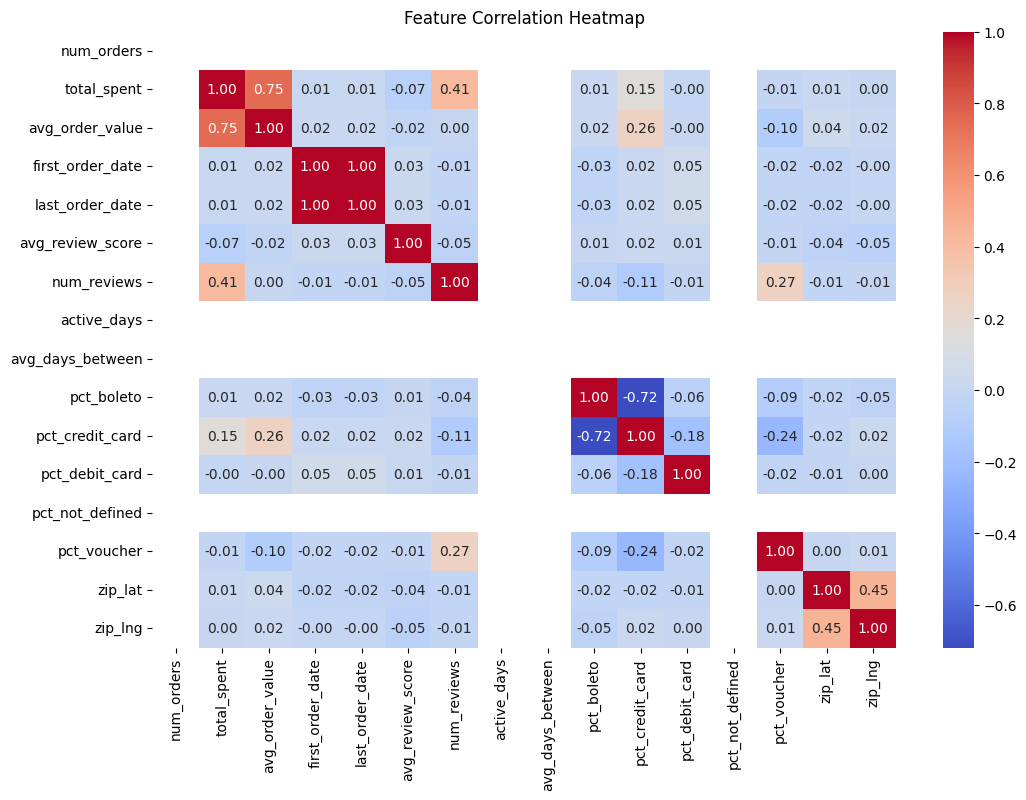

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(features.drop(columns=['cluster']).corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()


<ipython-input-90-5165d5202d0c>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cluster', data=features, palette='Set2')


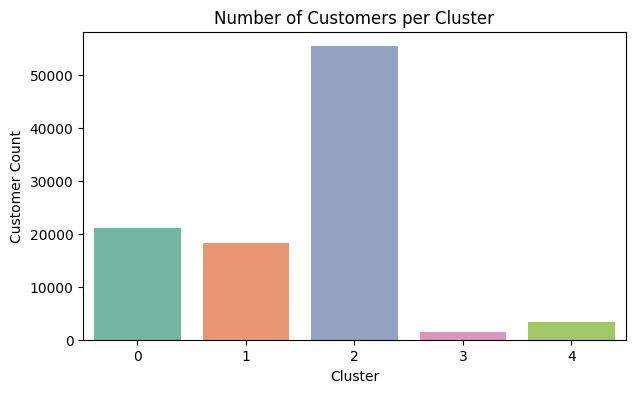

In [ ]:
plt.figure(figsize=(7, 4))
sns.countplot(x='cluster', data=features, palette='Set2')
plt.title('Number of Customers per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Customer Count')
plt.show()




---



## Baseline Clustering

### K means

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans,DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_samples, silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from sklearn.neighbors import NearestNeighbors
import umap.umap_ as umap

In [ ]:
X = features.select_dtypes(include=[np.number])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

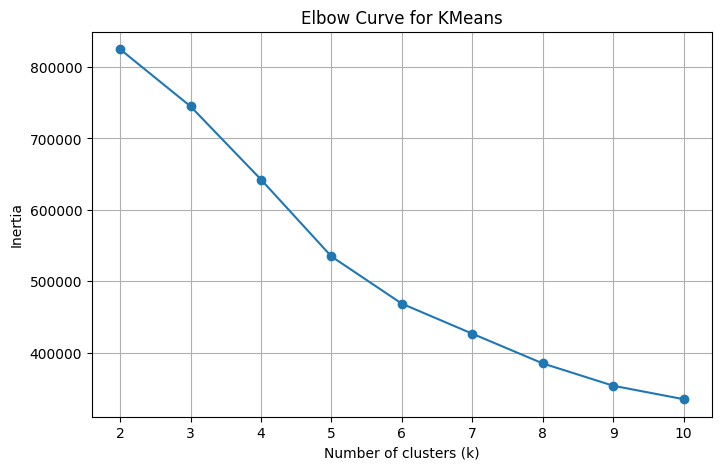

In [ ]:
inertia = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

#Elbow
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Curve for KMeans')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.grid(True)
plt.show()

In [ ]:
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init='auto')
features['cluster'] = kmeans_final.fit_predict(X_scaled)

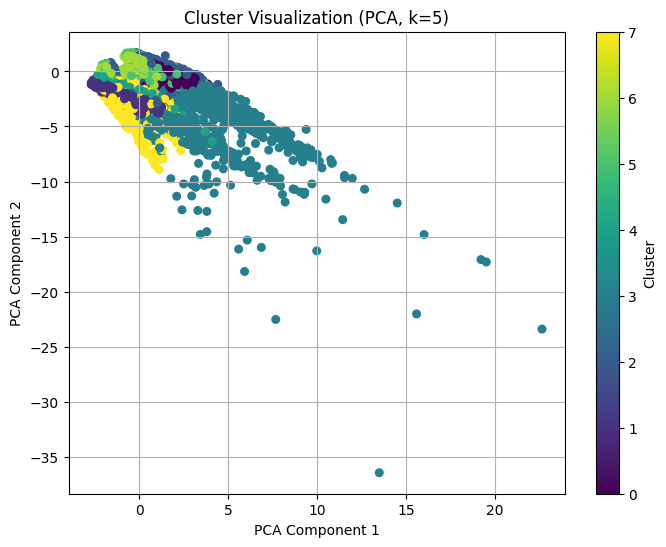

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=30)
plt.title('Cluster Visualization (PCA, k=5)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()


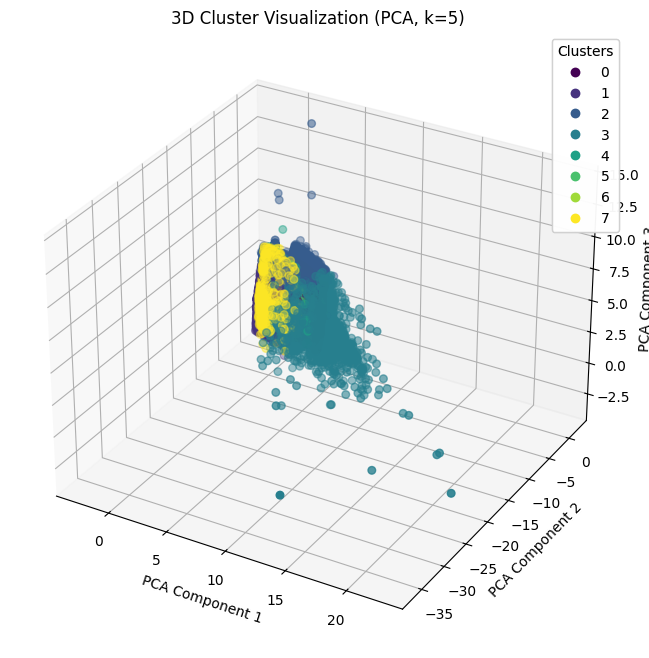

In [ ]:
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2],
                     c=labels, cmap='viridis', s=30)

ax.set_title('3D Cluster Visualization (PCA, k=5)')
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('PCA Component 3')

legend1 = ax.legend(*scatter.legend_elements(), title="Clusters", loc='upper right')
ax.add_artist(legend1)
plt.show()

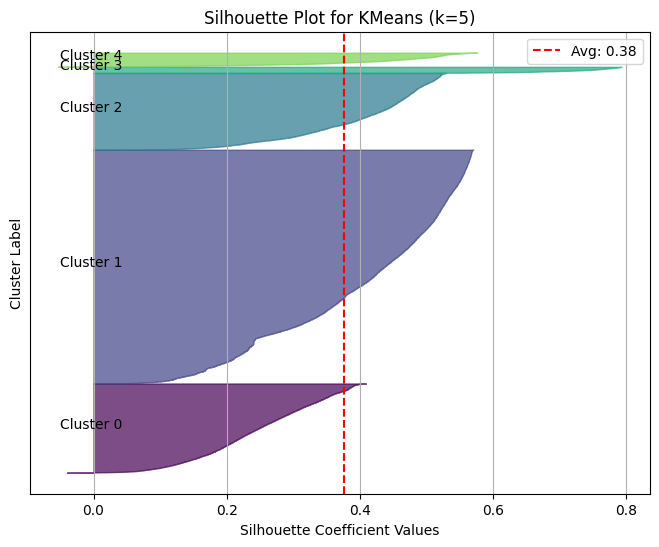

In [ ]:
X = features.select_dtypes(include=[np.number])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
labels = kmeans.fit_predict(X_scaled)

silhouette_vals = silhouette_samples(X_scaled, labels)
avg_silhouette = silhouette_score(X_scaled, labels)

# silhouette plot
fig, ax = plt.subplots(figsize=(8, 6))
y_lower = 10
for i in range(k):
    cluster_silhouette_vals = silhouette_vals[labels == i]
    cluster_silhouette_vals.sort()
    size_cluster_i = cluster_silhouette_vals.shape[0]
    y_upper = y_lower + size_cluster_i

    color = plt.cm.viridis(float(i) / k)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette_vals,
                     facecolor=color, edgecolor=color, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, f'Cluster {i}')
    y_lower = y_upper + 10

ax.axvline(avg_silhouette, color="red", linestyle="--", label=f'Avg: {avg_silhouette:.2f}')
ax.set_title("Silhouette Plot for KMeans (k=5)")
ax.set_xlabel("Silhouette Coefficient Values")
ax.set_ylabel("Cluster Label")
ax.set_yticks([])
ax.legend()
plt.grid(True)
plt.show()

In [ ]:
sil_score = silhouette_score(X_scaled, labels)
print(f"Silhouette Score (k=5): {sil_score:.4f}")

Silhouette Score (k=5): 0.3755




---



### Hierarchical Clustering

In [ ]:
X = features.select_dtypes(include=[np.number])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_scaled.shape

(99441, 14)

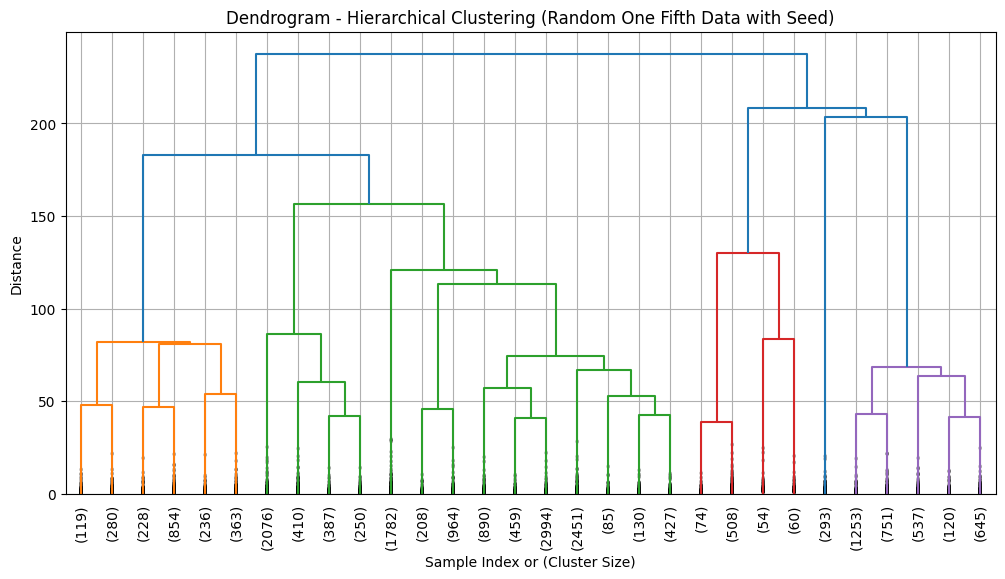

In [ ]:
np.random.seed(42)
n_samples = X_scaled.shape[0]
one_fifth = n_samples // 5

indices = np.random.choice(n_samples, one_fifth, replace=False)
X_one_fifth = X_scaled[indices]

linked = linkage(X_one_fifth, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=10, show_contracted=True)
plt.title('Dendrogram - Hierarchical Clustering (Random One Fifth Data with Seed)')
plt.xlabel('Sample Index or (Cluster Size)')
plt.ylabel('Distance')
plt.grid(True)
plt.show()

In [ ]:
k = 5
labels = fcluster(linked, k, criterion='maxclust')

features.loc[:, 'h_cluster'] = np.nan

features.iloc[indices, features.columns.get_loc('h_cluster')] = labels

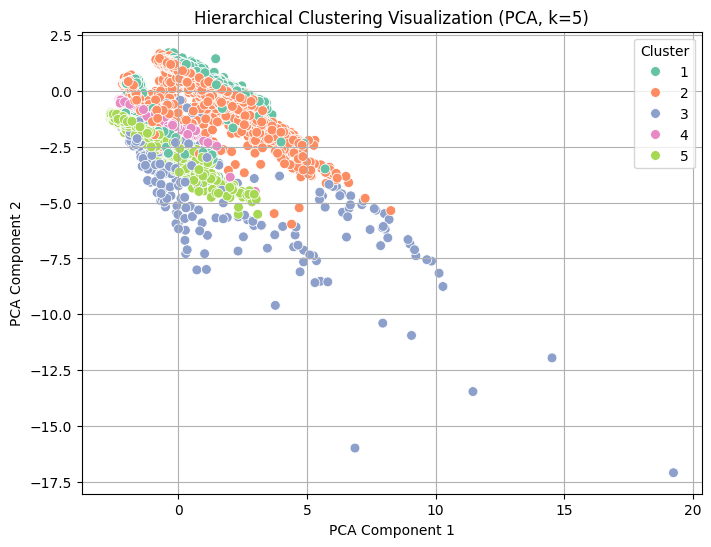

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))

sns.scatterplot(x=X_pca[indices, 0], y=X_pca[indices, 1], hue=labels, palette='Set2', s=50)

plt.title(f'Hierarchical Clustering Visualization (PCA, k={k})')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()


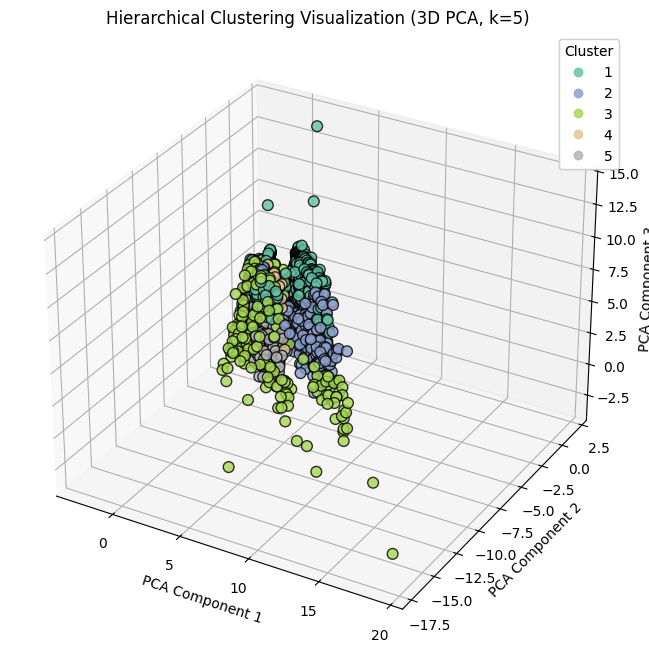

In [ ]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_pca[indices, 0],
    X_pca[indices, 1],
    X_pca[indices, 2],
    c=labels,
    cmap='Set2',
    s=60,
    edgecolor='k',
    alpha=0.8
)

ax.set_title(f'Hierarchical Clustering Visualization (3D PCA, k={k})')
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('PCA Component 3')

legend1 = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend1)

plt.show()

In [ ]:
sil_score = silhouette_score(X_one_fifth, labels)
print(f"Silhouette Score (k={k}): {sil_score:.4f}")


Silhouette Score (k=5): 0.3484


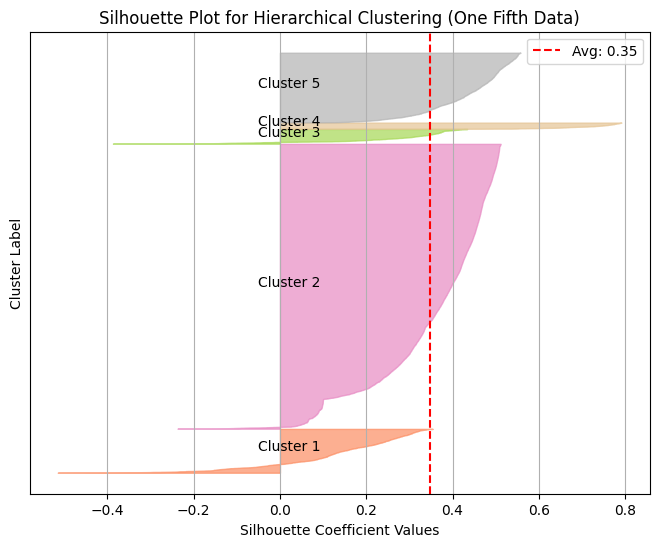

In [ ]:
silhouette_vals = silhouette_samples(X_one_fifth, labels)
avg_silhouette = silhouette_score(X_one_fifth, labels)

fig, ax = plt.subplots(figsize=(8, 6))
y_lower = 10
for i in range(1, k+1):
    cluster_vals = silhouette_vals[labels == i]
    cluster_vals.sort()
    size = cluster_vals.shape[0]
    y_upper = y_lower + size

    color = plt.cm.Set2(float(i) / k)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_vals,
                     facecolor=color, edgecolor=color, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size, f'Cluster {i}')
    y_lower = y_upper + 10

ax.axvline(avg_silhouette, color="red", linestyle="--", label=f'Avg: {avg_silhouette:.2f}')
ax.set_title("Silhouette Plot for Hierarchical Clustering (One Fifth Data)")
ax.set_xlabel("Silhouette Coefficient Values")
ax.set_ylabel("Cluster Label")
ax.set_yticks([])
ax.legend()
plt.grid(True)
plt.show()




---



### DBSCAN

In [ ]:
X = features.select_dtypes(include=[np.number])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


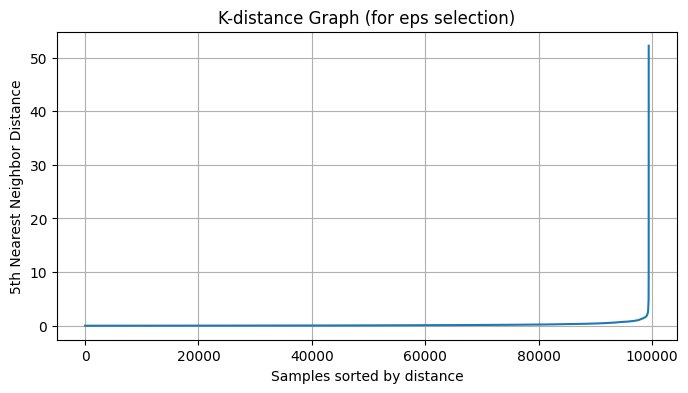

In [ ]:
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:, 4])  # k-th NN (k=5)

plt.figure(figsize=(8, 4))
plt.plot(distances)
plt.title('K-distance Graph (for eps selection)')
plt.xlabel('Samples sorted by distance')
plt.ylabel('5th Nearest Neighbor Distance')
plt.grid(True)
plt.show()


In [ ]:
seed = 42
sample_frac = 0.2
sample_indices = np.random.RandomState(seed).choice(len(X_scaled), size=int(len(X_scaled)*sample_frac), replace=False)
X_sampled = X_scaled[sample_indices]
dbscan = DBSCAN(eps=1.5, min_samples=5)
labels = dbscan.fit_predict(X_sampled)

sampled_df = features.iloc[sample_indices].copy()
sampled_df['db_cluster'] = labels

print(sampled_df[['db_cluster']].value_counts())

db_cluster
 0            14021
 1             3610
 2             1494
-1              323
 4              278
 3              104
 6               28
 5               11
 8                9
 7                6
 9                4
Name: count, dtype: int64


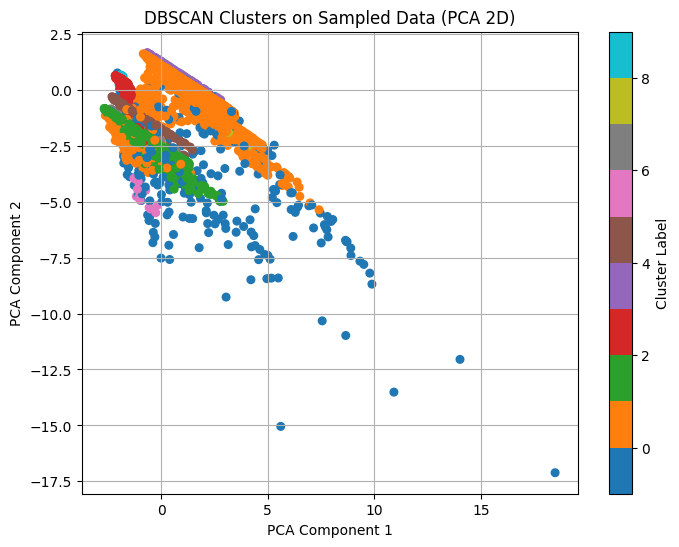

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sampled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10', s=30)
plt.title('DBSCAN Clusters on Sampled Data (PCA 2D)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(scatter, label='Cluster Label')
plt.grid(True)
plt.show()

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


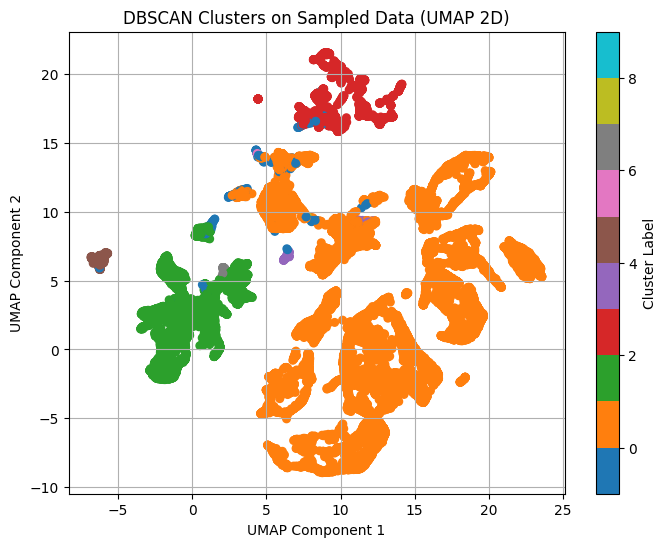

In [ ]:
umap_2d = umap.UMAP(n_components=2, random_state=42)
X_umap = umap_2d.fit_transform(X_sampled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=labels, cmap='tab10', s=30)
plt.title('DBSCAN Clusters on Sampled Data (UMAP 2D)')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.colorbar(scatter, label='Cluster Label')
plt.grid(True)
plt.show()

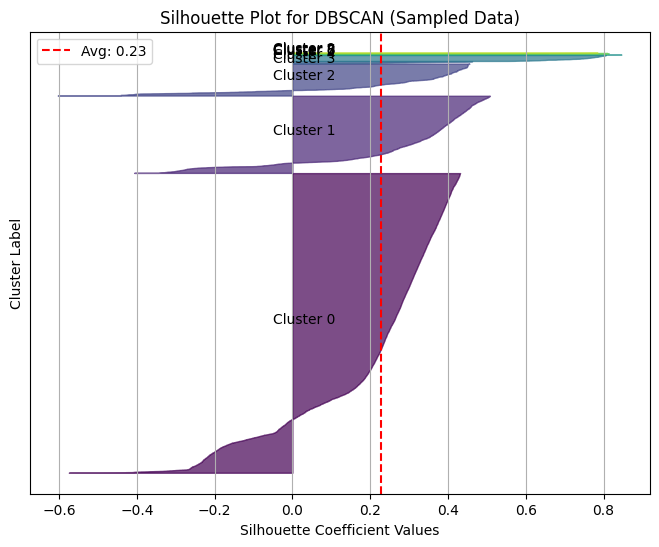

In [ ]:
mask = labels != -1
X_sampled_clustered = X_sampled[mask]
labels_clustered = labels[mask]


silhouette_vals = silhouette_samples(X_sampled_clustered, labels_clustered)
avg_silhouette = silhouette_score(X_sampled_clustered, labels_clustered)


fig, ax = plt.subplots(figsize=(8, 6))
y_lower = 10
n_clusters = len(set(labels_clustered))

for i in sorted(set(labels_clustered)):
    ith_cluster_silhouette_vals = silhouette_vals[labels_clustered == i]
    ith_cluster_silhouette_vals.sort()
    size_cluster_i = ith_cluster_silhouette_vals.shape[0]
    y_upper = y_lower + size_cluster_i

    color = plt.cm.viridis(float(i) / n_clusters)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_vals,
                     facecolor=color, edgecolor=color, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, f'Cluster {i}')
    y_lower = y_upper + 10

ax.axvline(avg_silhouette, color="red", linestyle="--", label=f'Avg: {avg_silhouette:.2f}')
ax.set_title("Silhouette Plot for DBSCAN (Sampled Data)")
ax.set_xlabel("Silhouette Coefficient Values")
ax.set_ylabel("Cluster Label")
ax.set_yticks([])
ax.legend()
plt.grid(True)
plt.show()

In [ ]:
mask = labels != -1
X_sampled_clustered = X_sampled[mask]
labels_clustered = labels[mask]
sil_score = silhouette_score(X_sampled_clustered, labels_clustered)
print(f"Silhouette Score for DBSCAN (sampled, noise removed): {sil_score:.4f}")

Silhouette Score for DBSCAN (sampled, noise removed): 0.2268




---



## Model Variants & Dimensionality Reduction

### Comparative Visualization of KMeans Clustering Results Using PCA, t-SNE, and UMAP on a Random Subset

In [ ]:
np.random.seed(42)
n_samples = X_scaled.shape[0]
one_fifth_size = n_samples // 5
random_indices = np.random.choice(n_samples, one_fifth_size, replace=False)

X_subset = X_scaled[random_indices]
labels_subset = labels.iloc[random_indices].reset_index(drop=True)


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


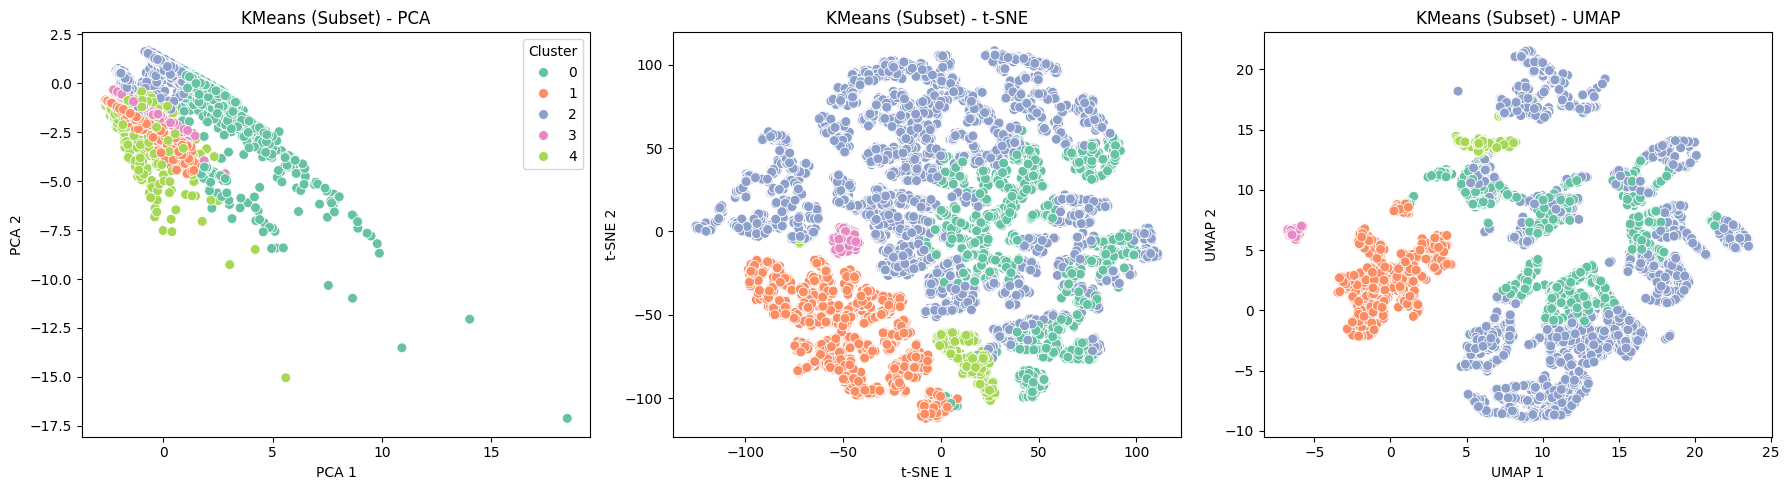

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# PCA
X_pca = PCA(n_components=2).fit_transform(X_subset)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels_subset, palette='Set2', ax=axs[0], s=50)
axs[0].set_title('KMeans (Subset) - PCA')
axs[0].set_xlabel('PCA 1')
axs[0].set_ylabel('PCA 2')
axs[0].legend(title='Cluster')

# t-SNE
X_tsne = TSNE(n_components=2, random_state=42).fit_transform(X_subset)
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=labels_subset, palette='Set2', ax=axs[1], s=50)
axs[1].set_title('KMeans (Subset) - t-SNE')
axs[1].set_xlabel('t-SNE 1')
axs[1].set_ylabel('t-SNE 2')
axs[1].legend().remove()

# UMAP
X_umap = umap.UMAP(random_state=42).fit_transform(X_subset)
sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=labels_subset, palette='Set2', ax=axs[2], s=50)
axs[2].set_title('KMeans (Subset) - UMAP')
axs[2].set_xlabel('UMAP 1')
axs[2].set_ylabel('UMAP 2')
axs[2].legend().remove()

plt.tight_layout()
plt.show()


### Hierarchical Clustering Analysis with Different Linkage Methods

Method: ward


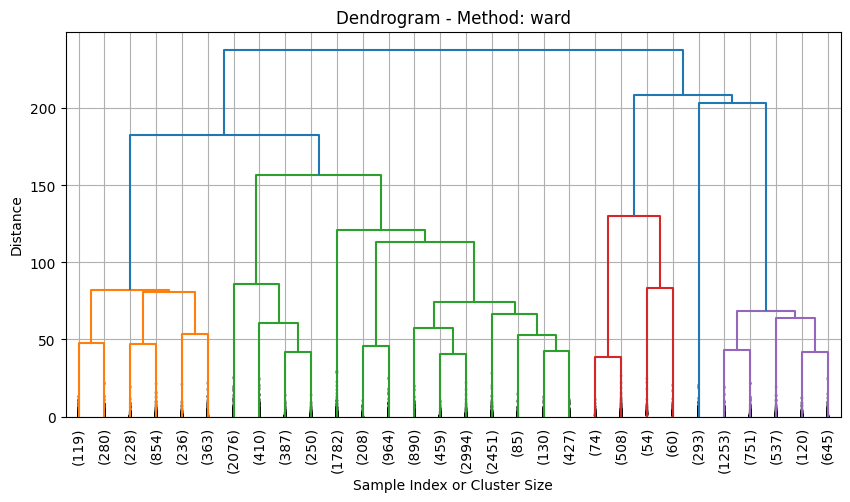

Silhouette Score: 0.3484
Davies-Bouldin Score: 1.1532


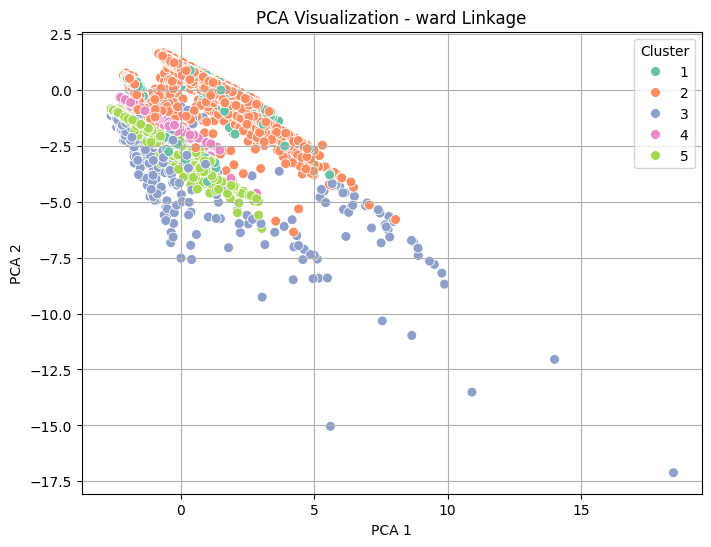

--------------------------------------------------
Method: complete


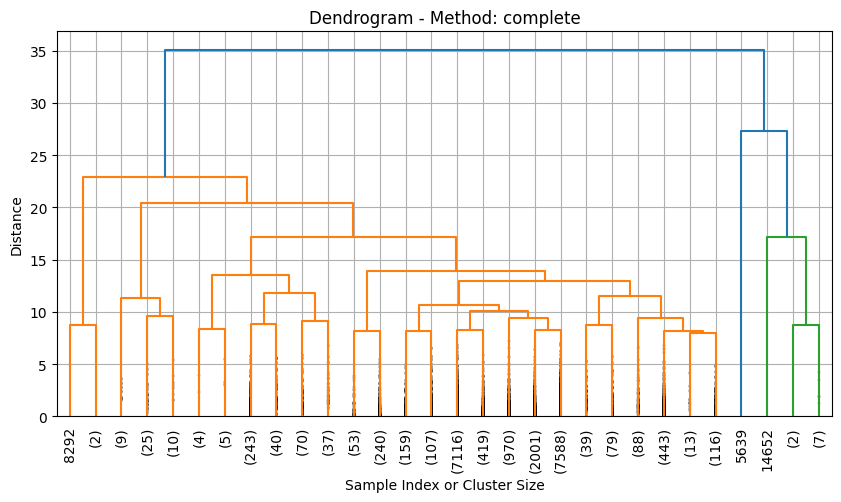

Silhouette Score: 0.6520
Davies-Bouldin Score: 0.5064


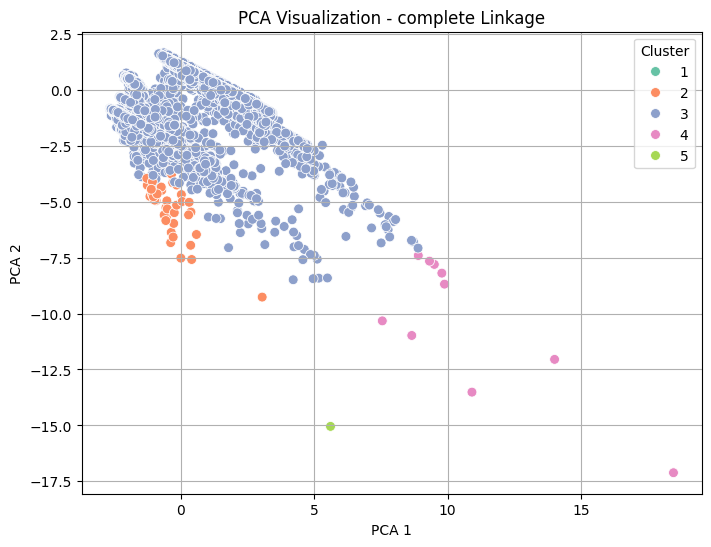

--------------------------------------------------
Method: average


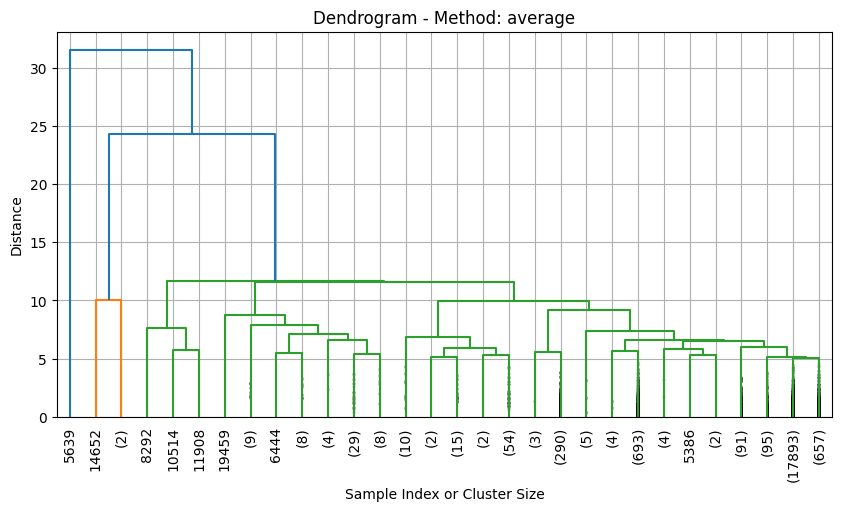

Silhouette Score: 0.6454
Davies-Bouldin Score: 0.5092


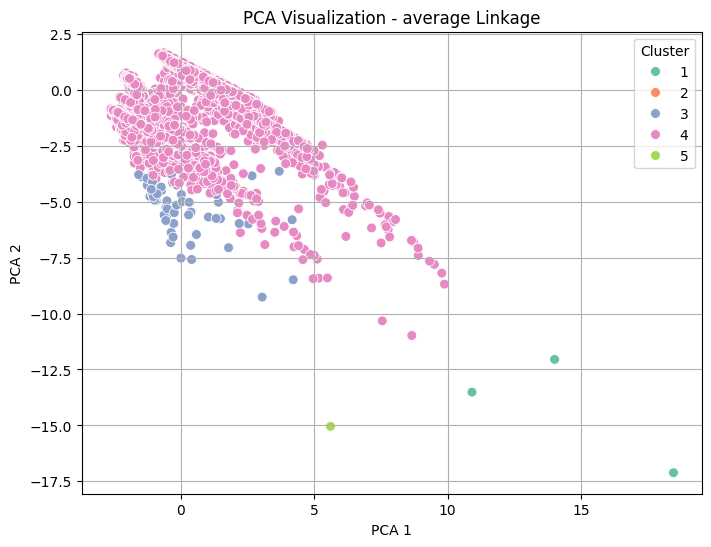

--------------------------------------------------


In [ ]:
np.random.seed(42)
n_samples = X_scaled.shape[0]
one_fifth = n_samples // 5
indices = np.random.choice(n_samples, one_fifth, replace=False)
X_sample = X_scaled[indices]

linkage_methods = ['ward','complete', 'average']

for method in linkage_methods:
    print(f"Method: {method}")


    linked = linkage(X_sample, method=method)


    plt.figure(figsize=(10, 5))
    dendrogram(linked, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=10, show_contracted=True)
    plt.title(f'Dendrogram - Method: {method}')
    plt.xlabel('Sample Index or Cluster Size')
    plt.ylabel('Distance')
    plt.grid(True)
    plt.show()


    labels = fcluster(linked, t=5, criterion='maxclust')


    sil_score = silhouette_score(X_sample, labels)
    db_score = davies_bouldin_score(X_sample, labels)
    print(f"Silhouette Score: {sil_score:.4f}")
    print(f"Davies-Bouldin Score: {db_score:.4f}")


    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_sample)

    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels, palette='Set2', s=50)
    plt.title(f'PCA Visualization - {method} Linkage')
    plt.xlabel('PCA 1')
    plt.ylabel('PCA 2')
    plt.legend(title='Cluster')
    plt.grid(True)
    plt.show()

    print('-' * 50)



---



### DBSCAN Clustering on UMAP-Reduced Data with Varying Hyperparameters


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


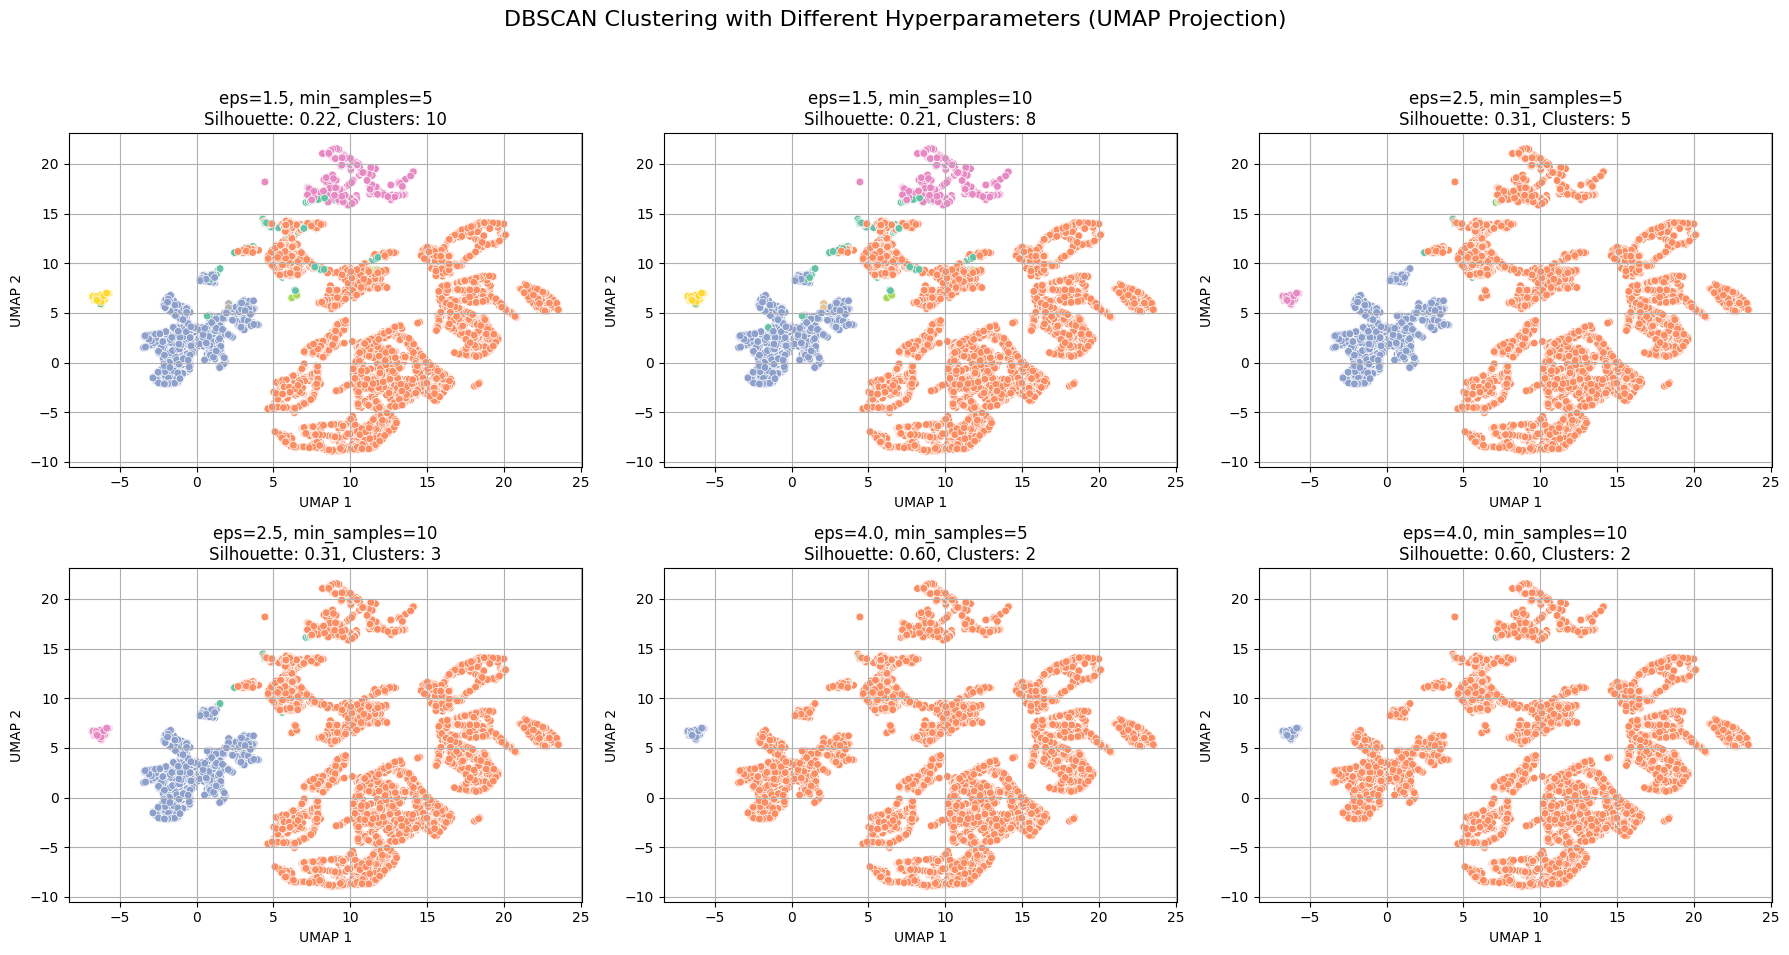

In [ ]:
np.random.seed(42)
n_samples = X_scaled.shape[0]
subset_size = n_samples // 5
indices = np.random.choice(n_samples, subset_size, replace=False)
X_subset = X_scaled[indices]

# UMAP
reducer = umap.UMAP(random_state=42)
X_umap = reducer.fit_transform(X_subset)


param_combinations = [(eps, ms) for eps in [1.5, 2.5, 4.0] for ms in [5, 10]]

plt.figure(figsize=(18, 10))
for i, (eps, min_samples) in enumerate(param_combinations, 1):
    db = DBSCAN(eps=eps, min_samples=min_samples)
    labels = db.fit_predict(X_subset)


    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    if n_clusters > 1:
        sil = silhouette_score(X_subset, labels)
    else:
        sil = -1

    plt.subplot(2, 3, i)
    sns.scatterplot(x=X_umap[:, 0], y=X_umap[:, 1], hue=labels, palette='Set2', s=30, legend=False)
    plt.title(f"eps={eps}, min_samples={min_samples}\nSilhouette: {sil:.2f}, Clusters: {n_clusters}")
    plt.xlabel('UMAP 1')
    plt.ylabel('UMAP 2')
    plt.grid(True)

plt.suptitle("DBSCAN Clustering with Different Hyperparameters (UMAP Projection)", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()



---



## Cluster Profiling & Business Insight

In [ ]:
cluster_profile = features.groupby('cluster').agg({
    'avg_order_value': ['mean', 'median'],
    'avg_review_score': 'mean',
    'total_spent': 'mean',
    'num_orders': 'mean',
    'pct_credit_card': 'mean',
    'pct_boleto': 'mean',
    'zip_lat': 'mean',
    'zip_lng': 'mean'
})

cluster_profile.columns = ['_'.join(col) for col in cluster_profile.columns]
cluster_profile.reset_index(inplace=True)


customer_counts = features['cluster'].value_counts().sort_index()
cluster_profile['Customer_Count'] = cluster_profile['cluster'].map(customer_counts)


marketing_labels = {
    0: "Low-spending loyalists",
    1: "Occasional boleto buyers",
    2: "Premium frequent buyers",
    3: "Average spenders, credit card fans",
    4: "Low activity users"
}

recommendations = {
    0: ["Offer loyalty discounts", "Reward long-term engagement"],
    1: ["Incentivize digital payments", "Send reminder emails"],
    2: ["VIP perks", "Early access to new products"],
    3: ["Cross-sell recommendations", "Time-limited offers"],
    4: ["Send reactivation campaigns", "Referral rewards"]
}

cluster_profile['Segment_Label'] = cluster_profile['cluster'].map(marketing_labels)
cluster_profile['Recommendation_1'] = cluster_profile['cluster'].map(lambda x: recommendations[x][0])
cluster_profile['Recommendation_2'] = cluster_profile['cluster'].map(lambda x: recommendations[x][1])


final_profile = cluster_profile[[
    'cluster', 'Segment_Label', 'avg_order_value_mean', 'avg_review_score_mean',
    'total_spent_mean', 'pct_credit_card_mean', 'pct_boleto_mean',
    'Customer_Count', 'Recommendation_1', 'Recommendation_2'
]]

final_profile.columns = [
    'Cluster', 'Segment Label', 'Avg Order Value', 'Avg Review Score',
    'Avg Total Spent', 'Credit Card %', 'Boleto %',
    'Customer Count', 'Recommendation 1', 'Recommendation 2'
]


display(final_profile)


,Cluster,Segment Label,Avg Order Value,Avg Review Score,Avg Total Spent,Credit Card %,Boleto %,Customer Count,Recommendation 1,Recommendation 2
0,0,Low-spending loyalists,206.956295,3.881207,276.672782,0.982929,0.015479,21125,Offer loyalty discounts,Reward long-term engagement
1,1,Occasional boleto buyers,104.081414,4.083787,116.082272,0.000000,1.000000,18177,Incentivize digital payments,Send reminder emails
2,2,Premium frequent buyers,67.530314,4.114272,70.328962,0.857343,0.000000,55362,VIP perks,Early access to new products
3,3,"Average spenders, credit card fans",104.143870,4.157074,122.656096,0.000000,0.000000,1442,Cross-sell recommendations,Time-limited offers
4,4,Low activity users,62.599150,3.977761,118.422423,0.115175,0.000000,3335,Send reactivation campaigns,Referral rewards
